### EDA OF FEATURES USED FOR FEATURE ENGINEERING

In [13]:
from src.data_ingestion.load_data import load_data
from src.utils.data_configs import BASE_TRAIN, BASE_DATA
import pandas as pd
import matplotlib.pyplot as plt



### Time Features - TransactionDT

In [6]:
df = load_data(BASE_TRAIN)
df.shape

2026-04-21 13:12:49,008 - INFO - src.data_ingestion.load_data - Loading Data From: /Users/salmanrasheed/Desktop/Projects/fraud-shield-gnn/data/base/train.csv
2026-04-21 13:12:52,407 - INFO - src.data_ingestion.load_data - Loaded data with 413,378 rows and 360 columns


(413378, 360)

In [10]:
df.columns

Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'id_20', 'id_28', 'id_29', 'id_31', 'id_35', 'id_36', 'id_37', 'id_38',
       'DeviceType', 'DeviceInfo'],
      dtype='object', length=360)

In [14]:
dt = df["TransactionDT"]

# ── Basic stats ───────────────────────────────────────
print(f"Nulls       : {dt.isnull().sum()}")        # expect 0
print(f"Min         : {dt.min()}")                  # 86400
print(f"Max         : {dt.max()}")                  # ~10.4M
print(f"Days span   : {(dt.max() - dt.min()) / 86400:.1f} days")

Nulls       : 0
Min         : 86400
Max         : 10437996
Days span   : 119.8 days


### Find Missing Values

In [12]:
df.TransactionDT.isnull().sum()


0

In [15]:
# ── Derived columns ───────────────────────────────────
df["hour"]            = (dt // 3600) % 24
df["day_of_week"]     = (dt // 86400) % 7
df["days_since_start"] = dt // 86400

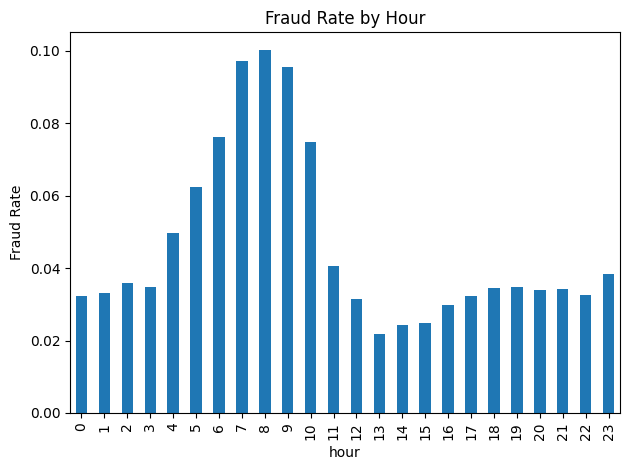

In [16]:
# ── Fraud rate by hour ─────────────────────────────────
fraud_by_hour = df.groupby("hour")["isFraud"].mean()
fraud_by_hour.plot(kind="bar", title="Fraud Rate by Hour")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

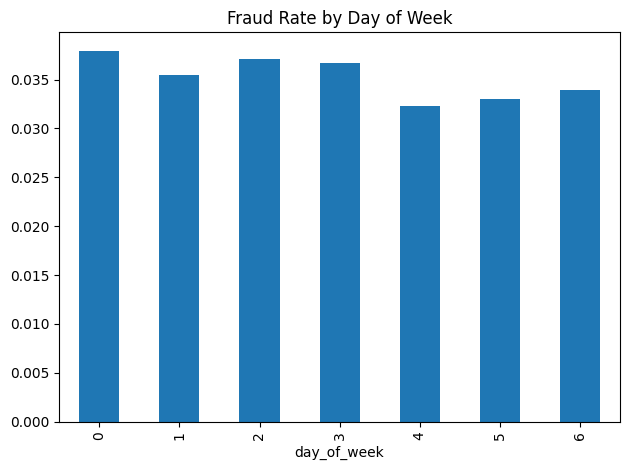

In [17]:
# ── Fraud rate by day of week ──────────────────────────
fraud_by_dow = df.groupby("day_of_week")["isFraud"].mean()
fraud_by_dow.plot(kind="bar", title="Fraud Rate by Day of Week")
plt.tight_layout()
plt.show()